# Linear Regression Error Metrics

We fit a linear regression model that predicts **ice creams sold** from the **temperature**, then measure how
wrong its predictions are using the five main error metrics:

| Metric | In one line |
|---|---|
| **MAE** (mean absolute error) | The average size of a miss |
| **MSE** (mean squared error) | The average of the squared misses, so big misses count extra |
| **RMSE** (root mean squared error) | The square root of MSE, back in the original units |
| **R²** | How much better the model is than always guessing the average |
| **MAPE** (mean absolute percentage error) | The average miss as a percentage |

The data is made up for teaching. Run each cell in order with Shift + Enter.

## 1. Fit the model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)

data = pd.DataFrame({
    "temperature": [14, 21, 23, 13, 15, 29, 13, 14, 29, 23, 19, 21, 24, 17, 14, 26, 24, 21, 27, 22, 30, 16, 22, 21],
    "ice_creams":  [49, 118, 138, 50, 62, 192, 75, 69, 183, 149, 121, 124, 159, 109, 70, 158, 156, 131, 189, 121, 192, 78, 115, 130],
})

X_train, X_test, y_train, y_test = train_test_split(
    data[["temperature"]], data["ice_creams"], test_size=0.25, random_state=42)

model = LinearRegression().fit(X_train, y_train)
predictions = model.predict(X_test)

print(f"Model: ice creams = {model.coef_[0]:.2f} x temperature {model.intercept_:+.2f}")
print(f"Trained on {len(X_train)} days, tested on {len(X_test)} days")

Model: ice creams = 7.84 x temperature -40.88
Trained on 18 days, tested on 6 days


## 2. Look at the errors

For each test day, the **error** is the actual value minus the predicted value. Positive means the shop sold more
than predicted; negative means it sold fewer.

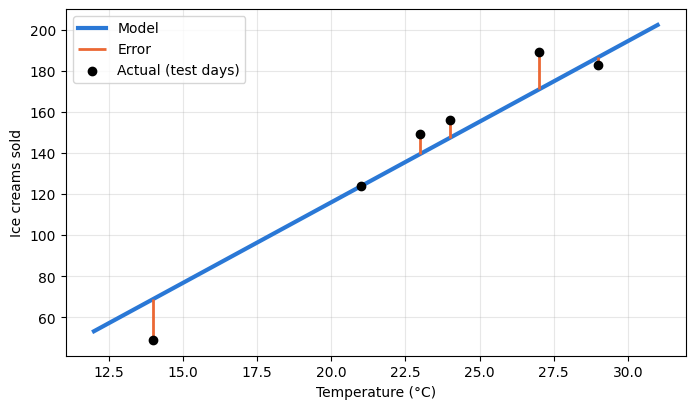

,temperature,actual,predicted,error,abs error,squared error,% error
8,29,183,186.6,-3.6,3.6,13.0,2.0
16,24,156,147.4,8.6,8.6,74.0,5.5
0,14,49,68.9,-19.9,19.9,396.0,40.6
18,27,189,170.9,18.1,18.1,327.6,9.6
11,21,124,123.8,0.2,0.2,0.0,0.2
9,23,149,139.5,9.5,9.5,90.2,6.4


In [2]:
results = pd.DataFrame({
    "temperature": X_test["temperature"],
    "actual": y_test,
    "predicted": predictions.round(1),
})
results["error"] = (results["actual"] - results["predicted"]).round(1)
results["abs error"] = results["error"].abs()
results["squared error"] = (results["error"] ** 2).round(1)
results["% error"] = (100 * results["abs error"] / results["actual"]).round(1)

plt.figure(figsize=(8, 4.5))
temps = np.array([[12], [31]])
plt.plot(temps, model.predict(pd.DataFrame(temps, columns=["temperature"])), color="#2a78d6", linewidth=3, label="Model")
plt.vlines(results["temperature"], results["predicted"], results["actual"], color="#eb6834", linewidth=2, label="Error")
plt.scatter(results["temperature"], results["actual"], color="black", zorder=3, label="Actual (test days)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Ice creams sold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

results

We cannot just average the errors, because the positive and negative ones cancel out. Each metric below deals with
that in a different way: MAE drops the minus signs, MSE and RMSE square the errors, and MAPE turns each one into a
percentage.

## 3. Calculate the metrics, by hand and with scikit-learn

In [3]:
errors = y_test - predictions

by_hand = {
    "MAE":  np.mean(np.abs(errors)),
    "MSE":  np.mean(errors ** 2),
    "RMSE": np.sqrt(np.mean(errors ** 2)),
    "R²":   1 - np.sum(errors ** 2) / np.sum((y_test - y_test.mean()) ** 2),
    "MAPE": np.mean(np.abs(errors) / y_test),
}

with_sklearn = {
    "MAE":  mean_absolute_error(y_test, predictions),
    "MSE":  mean_squared_error(y_test, predictions),
    "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
    "R²":   r2_score(y_test, predictions),
    "MAPE": mean_absolute_percentage_error(y_test, predictions),
}

pd.DataFrame({"by hand": by_hand, "scikit-learn": with_sklearn}).round(3)

,by hand,scikit-learn
MAE,9.979,9.979
MSE,150.300,150.300
RMSE,12.260,12.260
R²,0.931,0.931
MAPE,0.107,0.107


The two columns match, so the scikit-learn functions are doing exactly what the formulas say.

## 4. What the numbers mean

- **MAE ≈ 10:** on an average test day, the prediction is about 10 ice creams out. This is the easiest one to
  explain to someone else.
- **MSE ≈ 150:** this is in "ice creams squared", which is hard to picture. It is mostly useful for training and
  for comparing models, not for explaining results.
- **RMSE ≈ 12.3:** back in ice creams. It is bigger than the MAE because squaring gives extra weight to the two
  biggest misses (about 20 and 18 ice creams). A big gap between MAE and RMSE is a sign that a few errors are much
  larger than the rest.
- **R² ≈ 0.93:** the model removes about 93% of the squared error you would get by always predicting the average
  of the test days. 1 would be perfect, 0 would be no better than guessing the average.
- **MAPE ≈ 0.107:** scikit-learn gives this as a fraction, so it means about **10.7%**. Look at the `% error`
  column above: one cold day, with only 49 sales, is 40% out on its own and pulls the average up. MAPE punishes
  errors on small values, and it cannot be used at all if any actual value is 0.

For MAE, MSE, RMSE and MAPE, **lower is better**. For R², **higher is better**.

Always measure on the **test** data. The model has already seen the training data, so its scores there look
better than it really is.

## 5. Try it yourself

1. Work out the same five metrics on the **training** data, using `model.predict(X_train)`. Are they better or
   worse than the test scores? Why?
2. Change `random_state=42` to another number to get a different train/test split, then re-run all the cells.
   How much do the metrics change? What does that tell you about testing on only 6 days?
3. Change one actual value in the data to something unusual, such as 20 ice creams on a 28 °C day, and re-run.
   Which metric changes the most: MAE or RMSE?